<a href="https://colab.research.google.com/github/Anerig4/ipl_auction_analyzer/blob/main/IPL_2023_Analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏏 IPL Auction 2023 — Complete Analysis

**Run cells top-to-bottom. Cell 2 prompts you to upload your 3 CSV files.**

| File to upload | Kaggle dataset |
|---|---|
| `ipl_auction_2023.csv` | IPL Auction 2023 |
| `ipl_player_lifetime.csv` | IPL 2024 Player Lifetime Dataset |
| `ipl_points_table.csv` | IPL Points Table 2008-2024 |


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         IPL AUCTION 2023 · COMPLETE ANALYSIS NOTEBOOK           ║
# ║              Paste each cell block into Colab                   ║
# ╚══════════════════════════════════════════════════════════════════╝

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

# ── global plot style ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0a0c10",
    "axes.facecolor":    "#12161e",
    "axes.edgecolor":    "#2d3748",
    "axes.labelcolor":   "#94a3b8",
    "axes.titlecolor":   "#e2e8f0",
    "axes.titlesize":    14,
    "axes.labelsize":    11,
    "xtick.color":       "#64748b",
    "ytick.color":       "#64748b",
    "grid.color":        "#1e2530",
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
    "text.color":        "#e2e8f0",
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

PALETTE = ["#f5a623","#e84393","#38bdf8","#22c55e",
           "#a78bfa","#fb923c","#34d399","#f87171",
           "#fbbf24","#60a5fa","#4ade80","#f472b6"]

def section(title):
    """Print a styled section header."""
    bar = "═" * 70
    print(f"\n{bar}")
    print(f"  {title}")
    print(f"{bar}\n")

def subsection(title):
    print(f"\n── {title} {'─'*(60-len(title))}\n")

print("✅  Libraries loaded. Ready to go!")

✅  Libraries loaded. Ready to go!


In [3]:
from google.colab import files

print("Upload the 3 CSV files when prompted:")
print("  1. ipl_auction_2023.csv")
print("  2. ipl_player_lifetime.csv   (IPL 2024 Player Lifetime Dataset)")
print("  3. ipl_points_table.csv      (IPL Points Table 2008-2024)\n")

uploaded = files.upload()
print("\nUploaded files:", list(uploaded.keys()))

Upload the 3 CSV files when prompted:
  1. ipl_auction_2023.csv
  2. ipl_player_lifetime.csv   (IPL 2024 Player Lifetime Dataset)
  3. ipl_points_table.csv      (IPL Points Table 2008-2024)



Saving ipl_player_lifetime.csv to ipl_player_lifetime.csv
Saving ipl_points_table.csv to ipl_points_table.csv
Saving ipl_auction_2023.csv to ipl_auction_2023.csv

Uploaded files: ['ipl_player_lifetime.csv', 'ipl_points_table.csv', 'ipl_auction_2023.csv']


In [4]:
# ── Exact column names confirmed from diagnostic ───────────────────
# AUCTION    : name | player style | final price (in lacs) | franchise | status | nationality
# PLAYER     : Player_Name | Runs_Scored | Matches_Batted | Year  (+ wicket cols checked below)
# POINTS     : year | team | pos | points | Won | Lost

def load_auction(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()
    print(f"  Raw columns: {list(df.columns)}")

    # ── exact rename map (covers this Kaggle dataset precisely) ──
    rename = {}
    for c in df.columns:
        cl = c.lower().strip()
        if cl == "name":                           rename[c] = "Player"
        elif cl == "franchise":                    rename[c] = "Team"
        elif cl == "player style":                 rename[c] = "Role"
        elif "final price" in cl:                  rename[c] = "Price"
        elif "base price" in cl:                   rename[c] = "Base_Price"
        elif cl == "status":                       rename[c] = "Capped_Status"
        elif cl == "nationality":                  rename[c] = "Nationality"
    df.rename(columns=rename, inplace=True)

    # ── ensure required columns exist ────────────────────────────
    for col in ["Player", "Team", "Role", "Price"]:
        if col not in df.columns:
            df[col] = np.nan

    # ── Price: already in Lakhs → convert to rupees (*1e5) ───────
    df["Price"] = pd.to_numeric(df["Price"], errors="coerce").fillna(0) * 1e5

    df["Player"] = df["Player"].astype(str).str.strip()
    df["Team"]   = df["Team"].astype(str).str.strip()
    df["Role"]   = df["Role"].astype(str).str.strip()

    # ── Capped: derive from Nationality (India = capped, others = uncapped)
    # status column contains "Sold"/"Unsold" not capped info in this dataset
    if "Nationality" in df.columns:
        df["Capped"] = (df["Nationality"].str.strip().str.lower() == "india").astype(int)
    else:
        df["Capped"] = 0

    # ── drop unsold players (Price == 0) ─────────────────────────
    before = len(df)
    df = df[df["Price"] > 0].copy().reset_index(drop=True)
    print(f"  → Removed {before - len(df)} unsold players. Remaining: {len(df)}")
    print(f"  Mapped columns: {list(df.columns)}\n")
    return df


def load_player_stats(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()
    print(f"  Raw columns: {list(df.columns)[:10]} ...")

    # ── exact rename map ──────────────────────────────────────────
    rename = {}
    for c in df.columns:
        cl = c.lower().strip()
        if cl == "player_name":                    rename[c] = "Player"
        elif cl == "runs_scored":                  rename[c] = "Runs"
        elif cl == "matches_batted":               rename[c] = "Matches"
        elif "wicket" in cl and "taken" in cl:     rename[c] = "Wickets"
        elif cl in ("wickets", "wkts", "wickets_taken"): rename[c] = "Wickets"
        elif cl == "year":                         rename[c] = "Year"
        # fallback: any col with "wicket" gets mapped if Wickets not yet found
    df.rename(columns=rename, inplace=True)

    # If Wickets still missing, check remaining columns
    if "Wickets" not in df.columns:
        for c in df.columns:
            if "wicket" in c.lower() or "wkt" in c.lower():
                df.rename(columns={c: "Wickets"}, inplace=True)
                print(f"  → Mapped '{c}' → Wickets")
                break
    if "Wickets" not in df.columns:
        df["Wickets"] = 0
        print("  → No wickets column found; defaulting to 0")

    if "Player" not in df.columns:
        raise ValueError("Player stats CSV has no 'Player_Name' column.")

    df["Player"] = df["Player"].astype(str).str.strip()
    for col in ["Runs", "Wickets", "Matches"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # ── filter to 2023 ────────────────────────────────────────────
    if "Year" in df.columns:
        df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
        df23 = df[df["Year"] == 2023].copy()
        if not df23.empty:
            df = df23
            print(f"  → Filtered to 2023: {len(df)} rows")
        else:
            print("  → No 2023 rows; using all years as lifetime stats")
    else:
        print("  → No Year column; using all rows")

    # ── one row per player ────────────────────────────────────────
    df = df.groupby("Player", as_index=False).agg(
        {"Runs": "sum", "Wickets": "sum", "Matches": "sum"}
    )

    df["Runs_per_match"]    = np.where(df["Matches"] > 0, df["Runs"]    / df["Matches"], 0)
    df["Wickets_per_match"] = np.where(df["Matches"] > 0, df["Wickets"] / df["Matches"], 0)

    print(f"  → Aggregated to {len(df)} unique players\n")
    return df


def load_points_table(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()
    rename = {}
    for c in df.columns:
        cl = c.lower().strip()
        if cl == "team":     rename[c] = "Team"
        elif cl == "year":   rename[c] = "Year"
        elif cl == "points": rename[c] = "Points"
        elif cl == "won":    rename[c] = "Wins"
        elif cl == "lost":   rename[c] = "Losses"
        elif cl == "pos":    rename[c] = "Position"
    df.rename(columns=rename, inplace=True)
    if "Year" in df.columns:
        df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
        df23 = df[df["Year"] == 2023]
        return df23.reset_index(drop=True) if not df23.empty else df
    return df


def compute_roi(df):
    df = df.copy()
    df["Performance_Score"] = df["Runs_per_match"] + (df["Wickets_per_match"] * 20)
    price_cr = df["Price"] / 1e7          # convert rupees → crores
    df["ROI"] = np.where(price_cr > 0, df["Performance_Score"] / price_cr, 0)
    df["ROI"] = df["ROI"].round(4)
    return df


# ── detect uploaded filenames ──────────────────────────────────────
def find_file(keywords):
    for fname in uploaded.keys():
        fl = fname.lower()
        if all(k in fl for k in keywords):
            return fname
    return None

auction_file = find_file(["auction"])  or find_file(["ipl","2023"])
player_file  = find_file(["lifetime"]) or find_file(["player"])
points_file  = find_file(["points"])   or find_file(["table"])

print(f"Detected files:\n  Auction : {auction_file}\n  Player  : {player_file}\n  Points  : {points_file}\n")

# ── load ───────────────────────────────────────────────────────────
section("LOADING & CLEANING DATA")

print("📂 Auction dataset...")
auction = load_auction(auction_file)
print(f"   Shape: {auction.shape}\n")

print("📂 Player stats dataset...")
player_stats = load_player_stats(player_file)
print(f"   Shape: {player_stats.shape}\n")

print("📂 Points table dataset...")
points_table = load_points_table(points_file)
print(f"   Shape: {points_table.shape}\n")

# ── fuzzy name match helper ────────────────────────────────────────
# Player names between datasets may differ slightly (e.g. "V Kohli" vs "Virat Kohli")
# We do an exact merge first, then report match rate
df = auction.merge(
    player_stats[["Player","Runs","Wickets","Matches",
                  "Runs_per_match","Wickets_per_match"]],
    on="Player", how="left"
)

for col in ["Runs","Wickets","Matches","Runs_per_match","Wickets_per_match"]:
    df[col] = pd.to_numeric(df.get(col, 0), errors="coerce").fillna(0)

df = compute_roi(df)

matched   = (df["Matches"] > 0).sum()
unmatched = (df["Matches"] == 0).sum()

print(f"✅  Merged dataset : {df.shape[0]} players, {df.shape[1]} columns")
print(f"   Stats matched  : {matched}  ({matched/len(df)*100:.1f}%)")
print(f"   No stats found : {unmatched}  (ROI = 0 for these players)\n")

if matched == 0:
    print("⚠️  WARNING: 0 players matched between auction & stats datasets.")
    print("   Sample auction names :", list(auction['Player'].head(5)))
    print("   Sample stats names   :", list(player_stats['Player'].head(5)))
    print("   → Check for name format differences above.\n")

display(df[["Player","Team","Role","Price","Runs_per_match",
            "Wickets_per_match","Performance_Score","ROI","Capped"]].head(10))

Detected files:
  Auction : ipl_auction_2023.csv
  Player  : ipl_player_lifetime.csv
  Points  : ipl_points_table.csv


══════════════════════════════════════════════════════════════════════
  LOADING & CLEANING DATA
══════════════════════════════════════════════════════════════════════

📂 Auction dataset...
  Raw columns: ['Unnamed: 0', 'name', 'player style', 'nationality', 'base price (in lacs)', 'final price (in lacs)', 'franchise', 'status']
  → Removed 0 unsold players. Remaining: 309
  Mapped columns: ['Unnamed: 0', 'Player', 'Role', 'Nationality', 'Base_Price', 'Price', 'Team', 'Capped_Status', 'Capped']

   Shape: (309, 9)

📂 Player stats dataset...
  Raw columns: ['Year', 'Player_Name', 'Matches_Batted', 'Not_Outs', 'Runs_Scored', 'Highest_Score', 'Batting_Average', 'Balls_Faced', 'Batting_Strike_Rate', 'Centuries'] ...
  → Filtered to 2023: 162 rows
  → Aggregated to 162 unique players

   Shape: (162, 6)

📂 Points table dataset...
   Shape: (10, 10)

✅  Merged dataset : 309

,Player,Team,Role,Price,Runs_per_match,Wickets_per_match,Performance_Score,ROI,Capped
0,Harshit Rana,KKR,Bowler,2000000.0,0.0,0.833333,16.666667,83.3333,1
1,Ekant Sen,CSK,Batter,15000000.0,0.0,0.000000,0.000000,0.0000,1
2,Wayne Parnell,CSK,Allrounder,15000000.0,0.0,0.000000,0.000000,0.0000,0
3,Shakib Al Hasan,KKR,Allrounder,15000000.0,0.0,0.000000,0.000000,0.0000,0
4,Joe Root,RR,Batter,10000000.0,0.0,0.000000,0.000000,0.0000,0
5,Abdul Basith,RR,Allrounder,2000000.0,0.0,0.000000,0.000000,0.0000,1
6,Prashant Chopra,CSK,Allrounder,15000000.0,0.0,0.000000,0.000000,0.0000,1
7,Akeal Hosein,SRH,Bowler,10000000.0,0.0,0.000000,0.000000,0.0000,0
8,Raghav Goyal,MI,Bowler,2000000.0,0.0,0.000000,0.000000,0.0000,1
9,Yudhvir Singh Charak,LSG,Allrounder,2000000.0,0.0,0.000000,0.000000,0.0000,1



══════════════════════════════════════════════════════════════════════
  OVERVIEW · KEY METRICS
══════════════════════════════════════════════════════════════════════

  Total Players                309
  Teams                        10
  Total Auction Budget         ₹982.50 Cr
  Avg Player Price             ₹3.18 Cr
  Mean ROI                     11.0326
  Median ROI                   0.0000


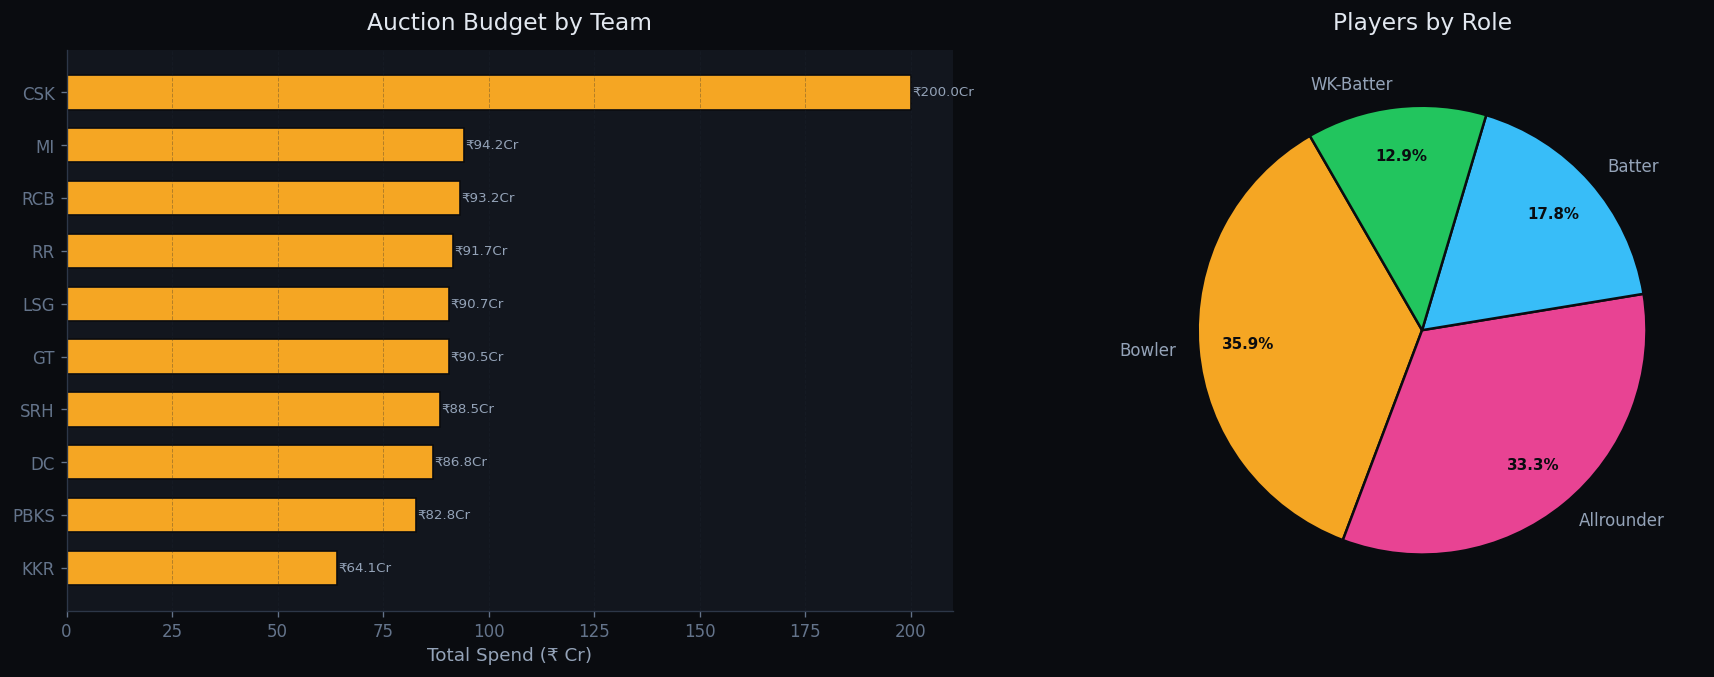

In [5]:
section("OVERVIEW · KEY METRICS")

total_players   = len(df)
total_teams     = df["Team"].nunique()
total_budget    = df["Price"].sum() / 1e7
avg_price       = df["Price"].mean() / 1e7
avg_roi         = df["ROI"].mean()
median_roi      = df["ROI"].median()

print(f"  {'Total Players':<28} {total_players}")
print(f"  {'Teams':<28} {total_teams}")
print(f"  {'Total Auction Budget':<28} ₹{total_budget:.2f} Cr")
print(f"  {'Avg Player Price':<28} ₹{avg_price:.2f} Cr")
print(f"  {'Mean ROI':<28} {avg_roi:.4f}")
print(f"  {'Median ROI':<28} {median_roi:.4f}")

# ── Team spend + Role distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0a0c10")

# Team spend bar
team_spend = df.groupby("Team")["Price"].sum().sort_values() / 1e7
ax = axes[0]
ax.set_facecolor("#12161e")
bars = ax.barh(team_spend.index, team_spend.values,
               color=PALETTE[0], edgecolor="#0a0c10", height=0.65)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"₹{bar.get_width():.1f}Cr", va="center", fontsize=8, color="#94a3b8")
ax.set_xlabel("Total Spend (₹ Cr)")
ax.set_title("Auction Budget by Team", pad=12)
ax.grid(axis="x", alpha=0.3)

# Role pie
role_counts = df["Role"].value_counts()
ax2 = axes[1]
ax2.set_facecolor("#12161e")
wedges, texts, autotexts = ax2.pie(
    role_counts.values, labels=role_counts.index,
    autopct="%1.1f%%", colors=PALETTE[:len(role_counts)],
    pctdistance=0.78, startangle=120,
    wedgeprops={"edgecolor":"#0a0c10","linewidth":1.5}
)
for t in texts:    t.set_color("#94a3b8"); t.set_fontsize(10)
for at in autotexts: at.set_color("#0a0c10"); at.set_fontsize(9); at.set_fontweight("bold")
ax2.set_title("Players by Role", pad=12)

plt.tight_layout(pad=2)
plt.show()


══════════════════════════════════════════════════════════════════════
  A) PLAYER ROI ANALYSIS
══════════════════════════════════════════════════════════════════════


── Top 10 Players by ROI (all teams) ───────────────────────────



,Player,Team,Role,Price,ROI,Performance_Score
0,Akash Madhwal,MI,Bowler,₹2.00e+06,175.0000,35.00
1,Matheesha Pathirana,CSK,Bowler,₹2.00e+06,158.3333,31.67
2,Atharva Taide,PBKS,Allrounder,₹2.00e+06,132.8571,26.57
3,Anmolpreet Singh,SRH,Batter,₹2.00e+06,131.2500,26.25
4,Tushar Deshpande,CSK,Bowler,₹2.00e+06,131.2500,26.25
5,Tristan Stubbs,MI,WK-Batter,₹2.00e+06,112.5000,22.50
6,Jitesh Sharma,PBKS,WK-Batter,₹2.00e+06,110.3571,22.07
7,Anukul Roy,KKR,Allrounder,₹2.00e+06,103.7500,20.75
8,Darshan Nalkande,GT,Bowler,₹2.00e+06,100.0000,20.00
9,Prerak Mankad,LSG,Allrounder,₹2.00e+06,93.0000,18.60


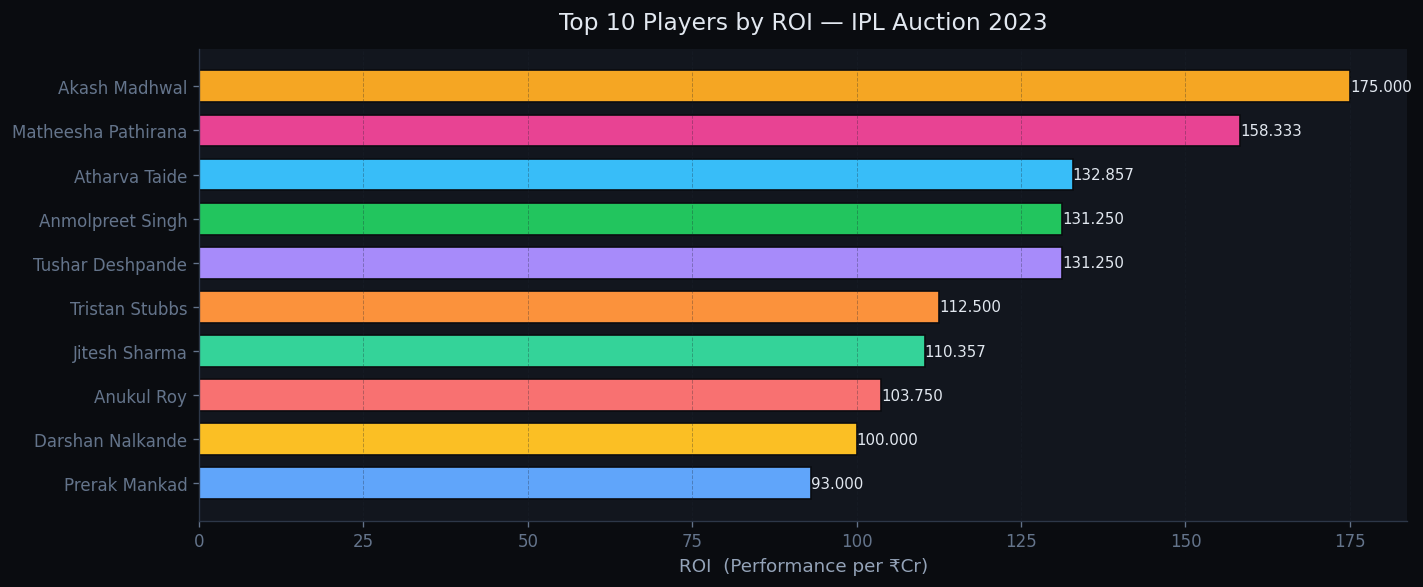


── Best ROI Player per Team ────────────────────────────────────



,Team,Player,Role,Price,ROI
5,MI,Akash Madhwal,Bowler,₹2.00e+06,175.0000
0,CSK,Matheesha Pathirana,Bowler,₹2.00e+06,158.3333
6,PBKS,Atharva Taide,Allrounder,₹2.00e+06,132.8571
9,SRH,Anmolpreet Singh,Batter,₹2.00e+06,131.2500
3,KKR,Anukul Roy,Allrounder,₹2.00e+06,103.7500
2,GT,Darshan Nalkande,Bowler,₹2.00e+06,100.0000
4,LSG,Prerak Mankad,Allrounder,₹2.00e+06,93.0000
7,RCB,Akash Deep,Bowler,₹2.00e+06,92.5000
8,RR,Dhruv Jurel,WK-Batter,₹2.00e+06,58.4615
1,DC,Ishant Sharma,Bowler,₹5.00e+06,50.2500


In [6]:
section("A) PLAYER ROI ANALYSIS")

# ── Top 10 overall ────────────────────────────────────────────────
top10 = df.nlargest(10, "ROI")[["Player","Team","Role","Price","ROI","Performance_Score"]].reset_index(drop=True)

subsection("Top 10 Players by ROI (all teams)")
display(top10.style
        .background_gradient(subset=["ROI"], cmap="YlOrRd")
        .format({"Price": "₹{:.2e}", "ROI": "{:.4f}", "Performance_Score": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top10))]
bars = ax.barh(top10["Player"], top10["ROI"], color=colors, edgecolor="#0a0c10", height=0.72)
for bar, val in zip(bars, top10["ROI"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9, color="#e2e8f0")
ax.set_xlabel("ROI  (Performance per ₹Cr)")
ax.set_title("Top 10 Players by ROI — IPL Auction 2023", pad=12)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Per-team top ROI ──────────────────────────────────────────────
subsection("Best ROI Player per Team")
best_per_team = (df.sort_values("ROI", ascending=False)
                   .groupby("Team").first()[["Player","Role","Price","ROI"]]
                   .reset_index()
                   .sort_values("ROI", ascending=False))
display(best_per_team.style
        .background_gradient(subset=["ROI"], cmap="YlGn")
        .format({"Price": "₹{:.2e}", "ROI": "{:.4f}"}))


══════════════════════════════════════════════════════════════════════
  B) TEAM STRATEGY BREAKDOWN
══════════════════════════════════════════════════════════════════════


  🏏 CSK..................................... ₹200.0 Cr  |  96 players  |  Avg ROI: 4.9527

  🏏 DC...................................... ₹86.8 Cr  |  24 players  |  Avg ROI: 6.2314

  🏏 GT...................................... ₹90.5 Cr  |  25 players  |  Avg ROI: 12.7739

  🏏 KKR..................................... ₹64.1 Cr  |  19 players  |  Avg ROI: 20.6729

  🏏 LSG..................................... ₹90.7 Cr  |  25 players  |  Avg ROI: 18.1748

  🏏 MI...................................... ₹94.2 Cr  |  23 players  |  Avg ROI: 24.6032

  🏏 PBKS.................................... ₹82.8 Cr  |  22 players  |  Avg ROI: 18.8810

  🏏 RCB..................................... ₹93.2 Cr  |  25 players  |  Avg ROI: 8.4626

  🏏 RR...................................... ₹91.7 Cr  |  25 players  |  Avg ROI: 4.3091

  🏏 SRH...

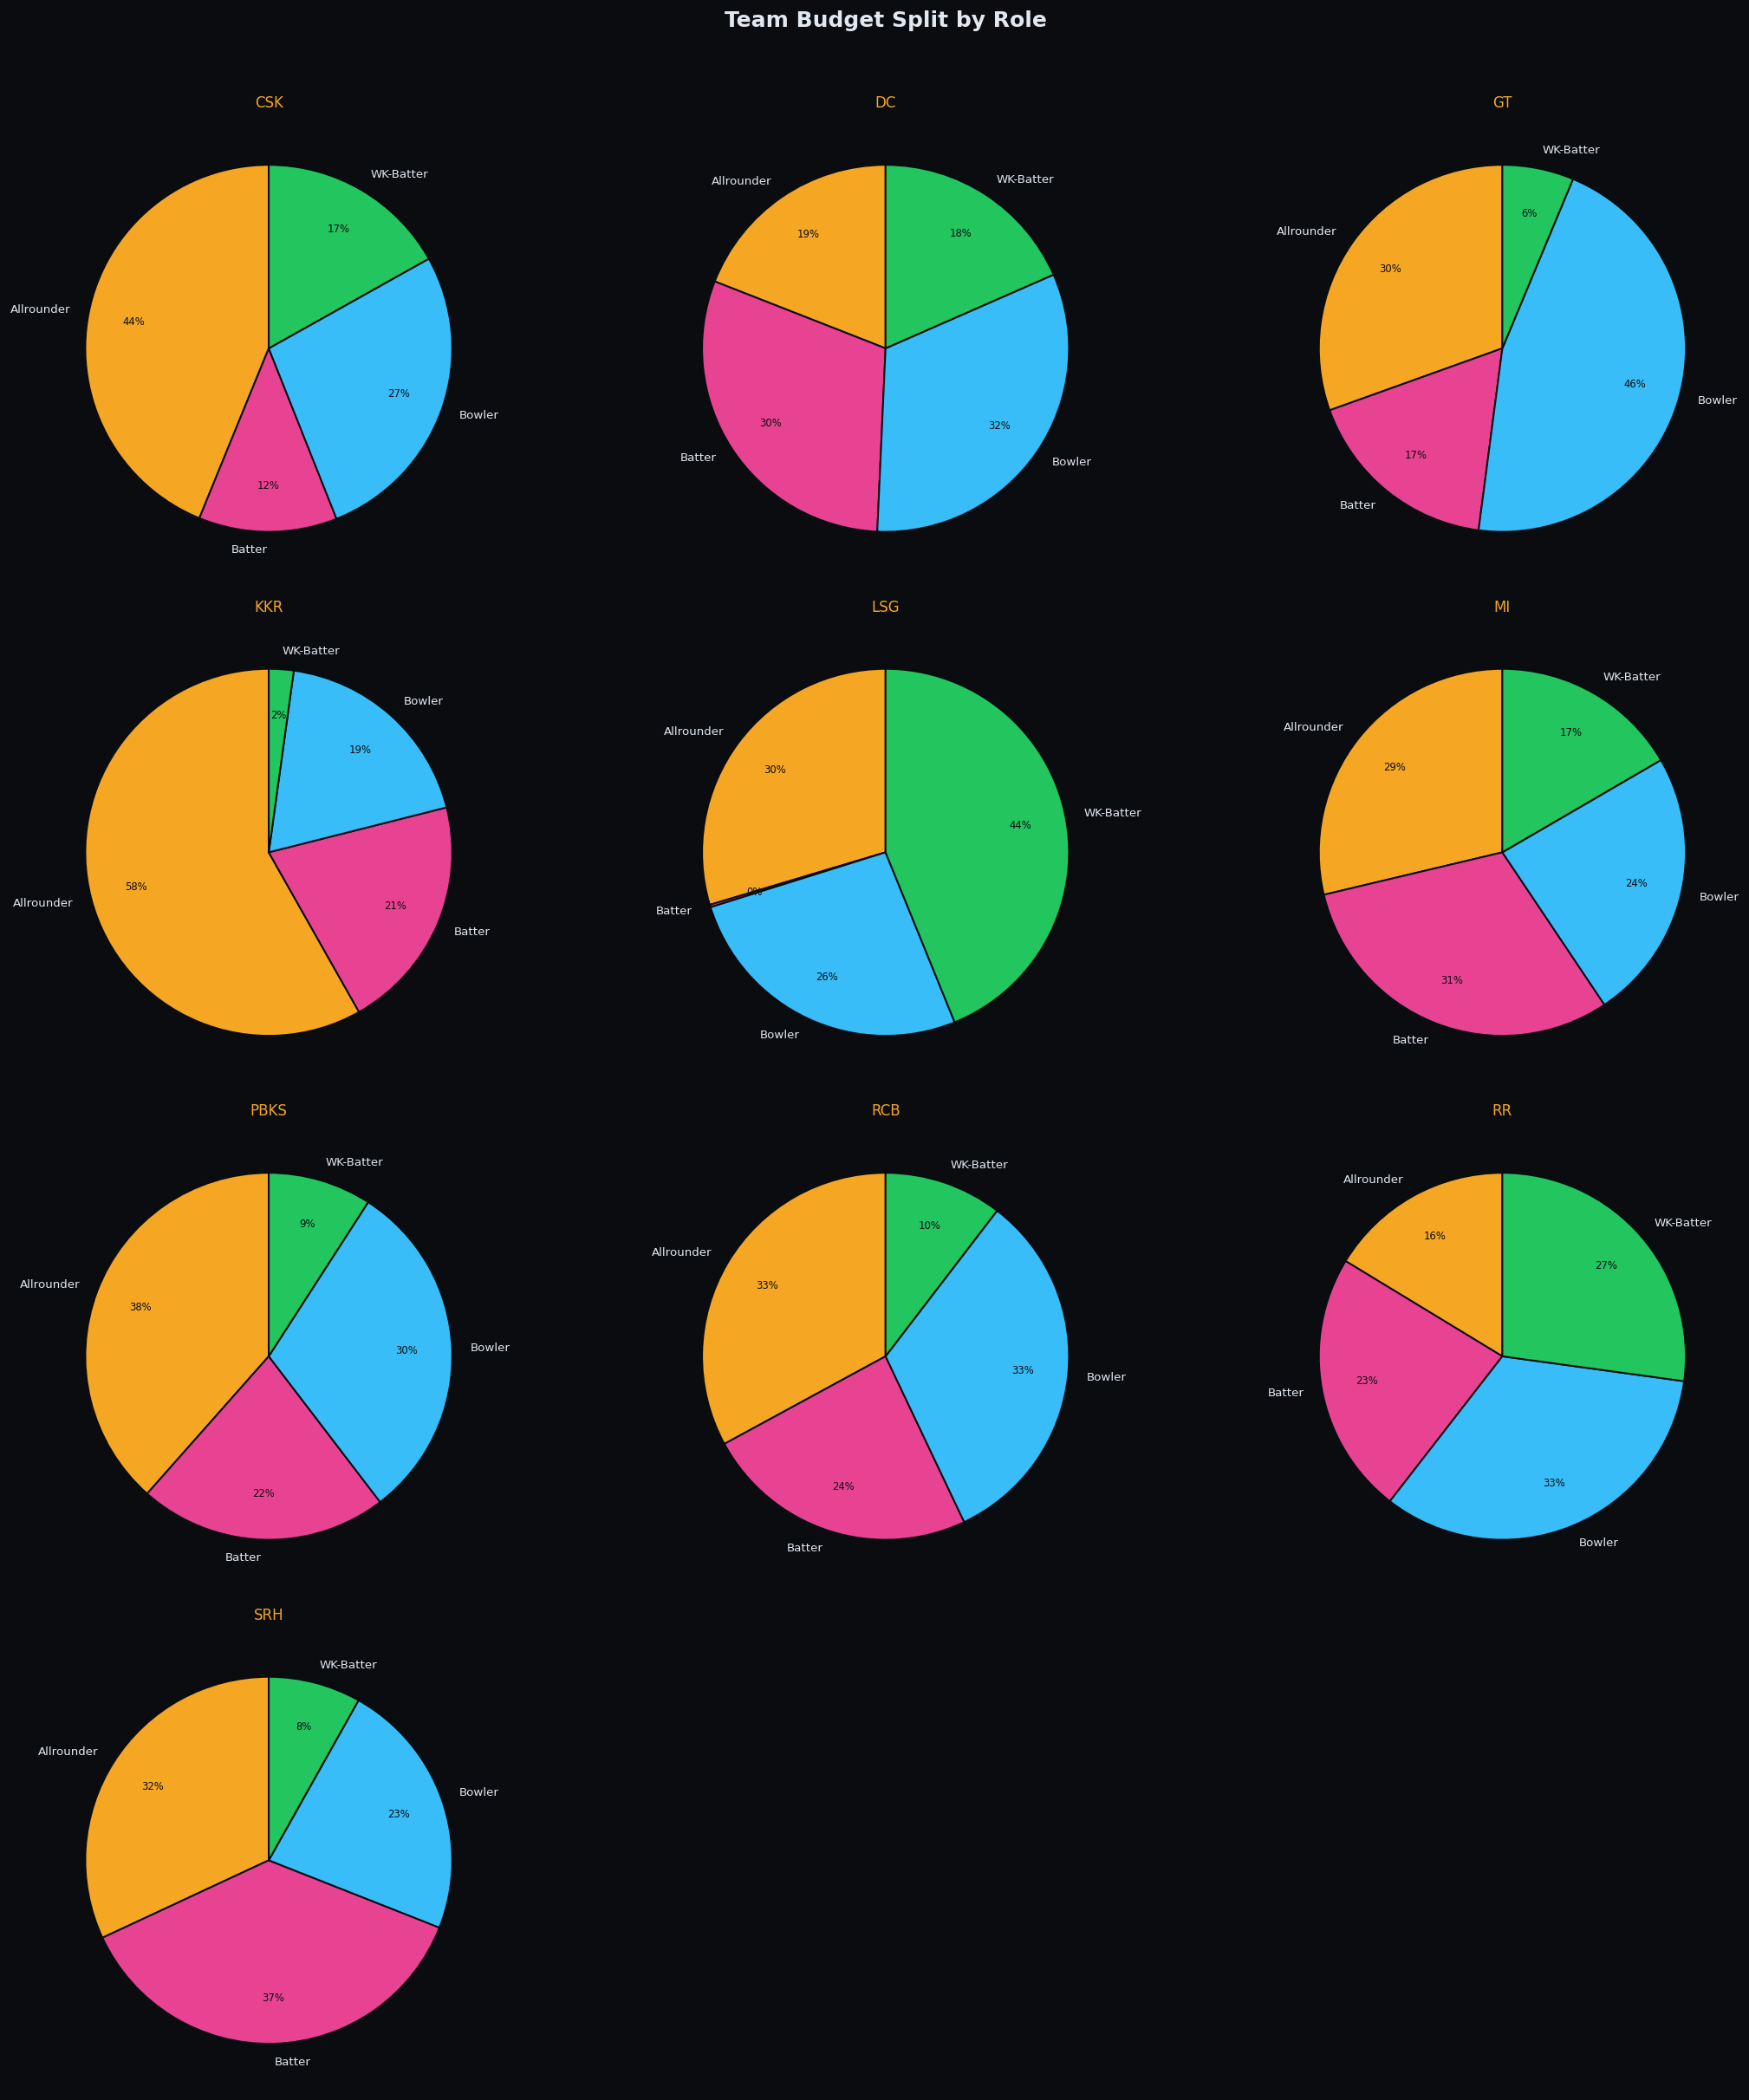

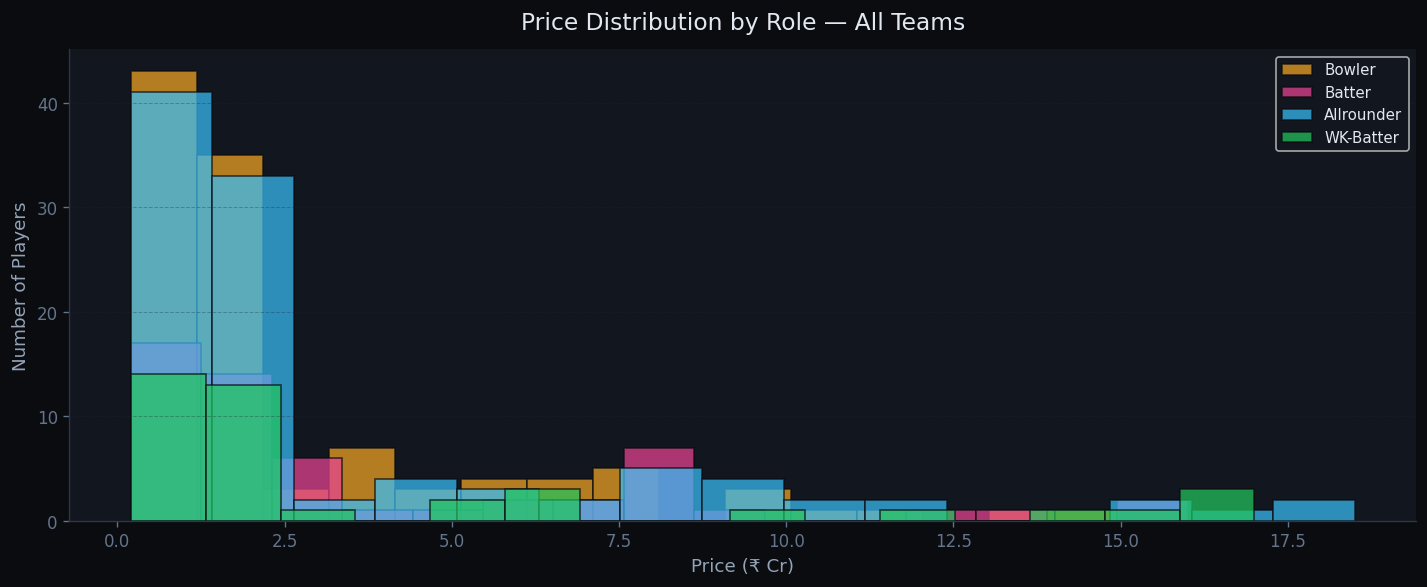


── All Players · Price & ROI ───────────────────────────────────



,Player,Team,Role,Price,Runs_per_match,Wickets_per_match,Performance_Score,ROI
0,Akash Madhwal,MI,Bowler,₹2.00e+06,0.00,1.750,35.00,175.0000
1,Matheesha Pathirana,CSK,Bowler,₹2.00e+06,0.00,1.583,31.67,158.3333
2,Atharva Taide,PBKS,Allrounder,₹2.00e+06,26.57,0.000,26.57,132.8571
3,Tushar Deshpande,CSK,Bowler,₹2.00e+06,0.00,1.312,26.25,131.2500
4,Anmolpreet Singh,SRH,Batter,₹2.00e+06,26.25,0.000,26.25,131.2500
5,Tristan Stubbs,MI,WK-Batter,₹2.00e+06,12.50,0.500,22.50,112.5000
6,Jitesh Sharma,PBKS,WK-Batter,₹2.00e+06,22.07,0.000,22.07,110.3571
7,Anukul Roy,KKR,Allrounder,₹2.00e+06,5.75,0.750,20.75,103.7500
8,Darshan Nalkande,GT,Bowler,₹2.00e+06,0.00,1.000,20.00,100.0000
9,Prerak Mankad,LSG,Allrounder,₹2.00e+06,18.60,0.000,18.60,93.0000


In [7]:
section("B) TEAM STRATEGY BREAKDOWN")

teams = sorted(df["Team"].dropna().unique())

for team in teams:
    tdf = df[df["Team"] == team]
    total_sp  = tdf["Price"].sum() / 1e7
    n_players = len(tdf)
    avg_r     = tdf["ROI"].mean()

    print(f"\n  🏏 {team:.<40} ₹{total_sp:.1f} Cr  |  {n_players} players  |  Avg ROI: {avg_r:.4f}")

# ── one combined figure: budget pie + price histogram per team ─────
n_teams = len(teams)
ncols   = 3
nrows   = int(np.ceil(n_teams / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
fig.patch.set_facecolor("#0a0c10")
axes_flat = axes.ravel() if n_teams > 1 else [axes]

for idx, team in enumerate(teams):
    ax = axes_flat[idx]
    ax.set_facecolor("#12161e")
    tdf = df[df["Team"] == team]
    role_budget = tdf.groupby("Role")["Price"].sum() / 1e7
    wedges, texts, autotexts = ax.pie(
        role_budget.values, labels=role_budget.index,
        autopct="%1.0f%%", colors=PALETTE[:len(role_budget)],
        startangle=90, pctdistance=0.75,
        wedgeprops={"edgecolor":"#0a0c10","linewidth":1.2}
    )
    for t in texts:    t.set_color("#e2e8f0"); t.set_fontsize(8)
    for at in autotexts: at.set_color("#0a0c10"); at.set_fontsize(7)
    ax.set_title(f"{team}", fontsize=10, color="#f5a623", pad=8)

for j in range(idx+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Team Budget Split by Role", fontsize=15,
             color="#e2e8f0", y=1.01, fontweight="bold")
plt.tight_layout(pad=1.5)
plt.show()

# ── Price distribution histogram per role (all teams combined) ─────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
for i, role in enumerate(df["Role"].dropna().unique()):
    vals = df[df["Role"] == role]["Price"] / 1e7
    ax.hist(vals, bins=15, alpha=0.72, label=role,
            color=PALETTE[i % len(PALETTE)], edgecolor="#0a0c10")
ax.set_xlabel("Price (₹ Cr)")
ax.set_ylabel("Number of Players")
ax.set_title("Price Distribution by Role — All Teams", pad=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── Full player table with ROI ─────────────────────────────────────
subsection("All Players · Price & ROI")
show = ["Player","Team","Role","Price","Runs_per_match",
        "Wickets_per_match","Performance_Score","ROI"]
show = [c for c in show if c in df.columns]
display(df[show].sort_values("ROI", ascending=False)
        .reset_index(drop=True)
        .style.background_gradient(subset=["ROI"], cmap="RdYlGn")
        .format({"Price":"₹{:.2e}","ROI":"{:.4f}",
                 "Runs_per_match":"{:.2f}","Wickets_per_match":"{:.3f}",
                 "Performance_Score":"{:.2f}"}))


══════════════════════════════════════════════════════════════════════
  C) UNCAPPED GEMS
══════════════════════════════════════════════════════════════════════

  Total uncapped players  : 108
  ROI 75th percentile     : 3.2732
  Gems (ROI ≥ Q75)        : 27


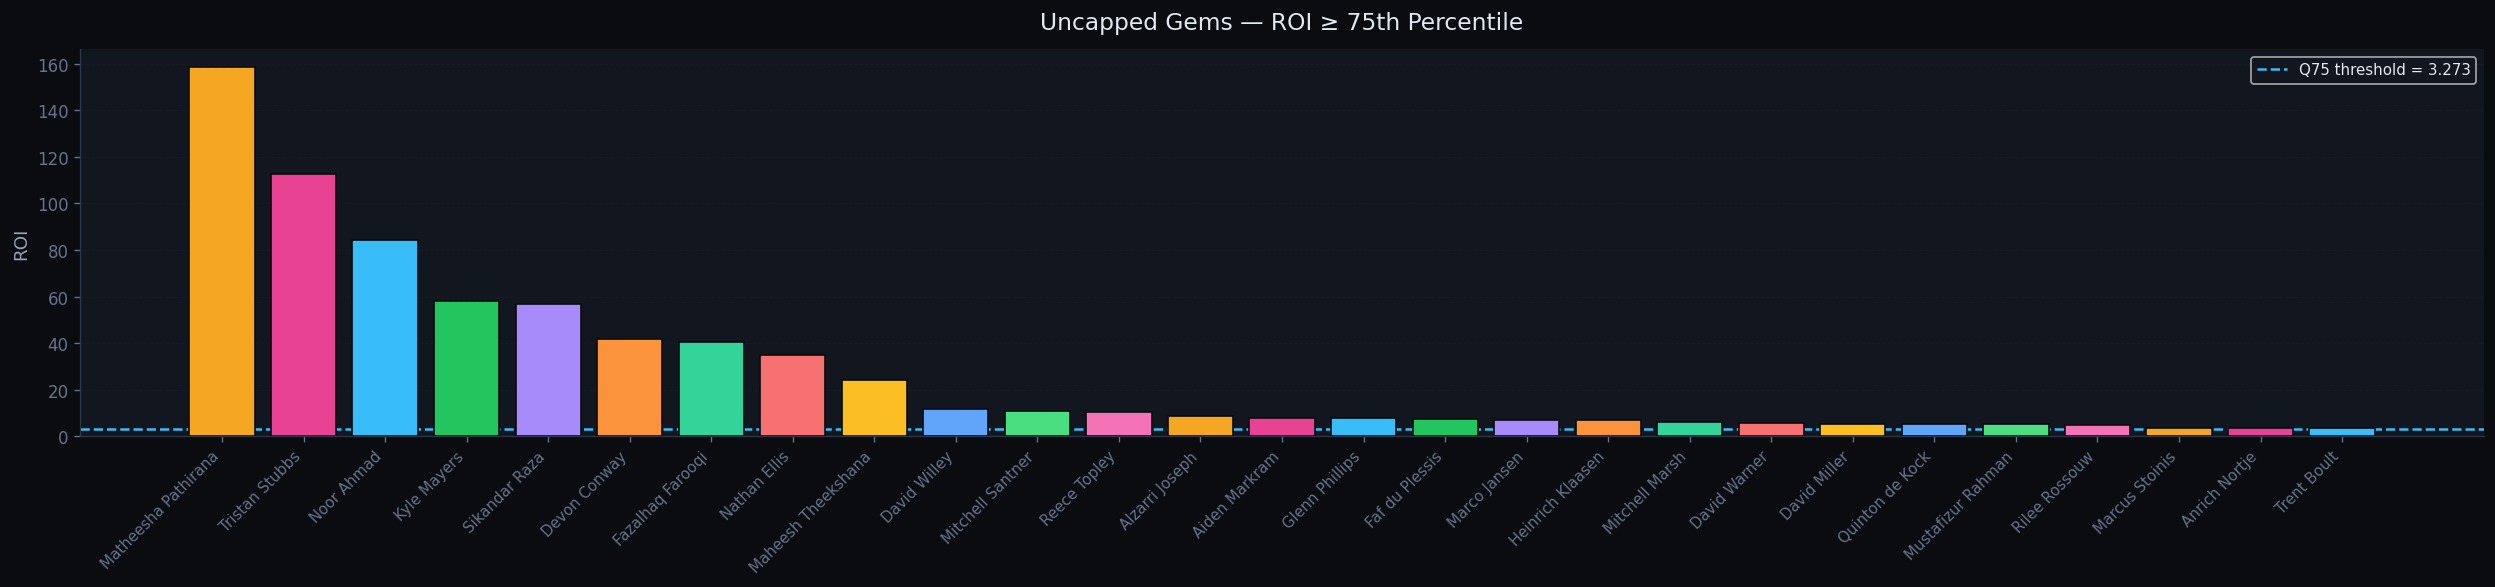

,Player,Team,Role,Price,ROI,Performance_Score
0,Matheesha Pathirana,CSK,Bowler,₹2.00e+06,158.3333,31.67
1,Tristan Stubbs,MI,WK-Batter,₹2.00e+06,112.5000,22.50
2,Noor Ahmad,GT,Bowler,₹3.00e+06,84.1026,25.23
3,Kyle Mayers,LSG,Allrounder,₹5.00e+06,58.3077,29.15
4,Sikandar Raza,PBKS,Allrounder,₹5.00e+06,56.8571,28.43
5,Devon Conway,CSK,Batter,₹1.00e+07,42.0000,42.00
6,Fazalhaq Farooqi,SRH,Bowler,₹5.00e+06,40.5000,20.25
7,Nathan Ellis,PBKS,Bowler,₹7.50e+06,34.8000,26.10
8,Maheesh Theekshana,CSK,Bowler,₹7.00e+06,24.1758,16.92
9,David Willey,RCB,Allrounder,₹2.00e+07,11.8750,23.75


In [8]:
section("C) UNCAPPED GEMS")

uncapped = df[df["Capped"] == 0].copy()

if uncapped.empty:
    print("⚠️  No uncapped players found. Check that your auction CSV has a 'Capped' column (0 = uncapped, 1 = capped).")
else:
    q75 = uncapped["ROI"].quantile(0.75)
    gems = uncapped[uncapped["ROI"] >= q75].sort_values("ROI", ascending=False).reset_index(drop=True)

    print(f"  Total uncapped players  : {len(uncapped)}")
    print(f"  ROI 75th percentile     : {q75:.4f}")
    print(f"  Gems (ROI ≥ Q75)        : {len(gems)}")

    # Bar chart
    fig, ax = plt.subplots(figsize=(max(10, len(gems)*0.7 + 2), 5))
    fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(gems))]
    ax.bar(gems["Player"], gems["ROI"], color=colors, edgecolor="#0a0c10", zorder=3)
    ax.axhline(q75, color="#38bdf8", linestyle="--", lw=1.5,
               label=f"Q75 threshold = {q75:.3f}")
    ax.set_xticklabels(gems["Player"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("ROI")
    ax.set_title("Uncapped Gems — ROI ≥ 75th Percentile", pad=12)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

    show = [c for c in ["Player","Team","Role","Price","ROI","Performance_Score"] if c in gems.columns]
    display(gems[show].style
            .background_gradient(subset=["ROI"], cmap="YlGn")
            .format({"Price":"₹{:.2e}","ROI":"{:.4f}","Performance_Score":"{:.2f}"}))


══════════════════════════════════════════════════════════════════════
  D) BENCH WARMERS · MONEY WASTED
══════════════════════════════════════════════════════════════════════

  Median price threshold  : ₹1.50 Cr
  ROI 25th percentile     : 0.0000
  Bench warmers identified: 0



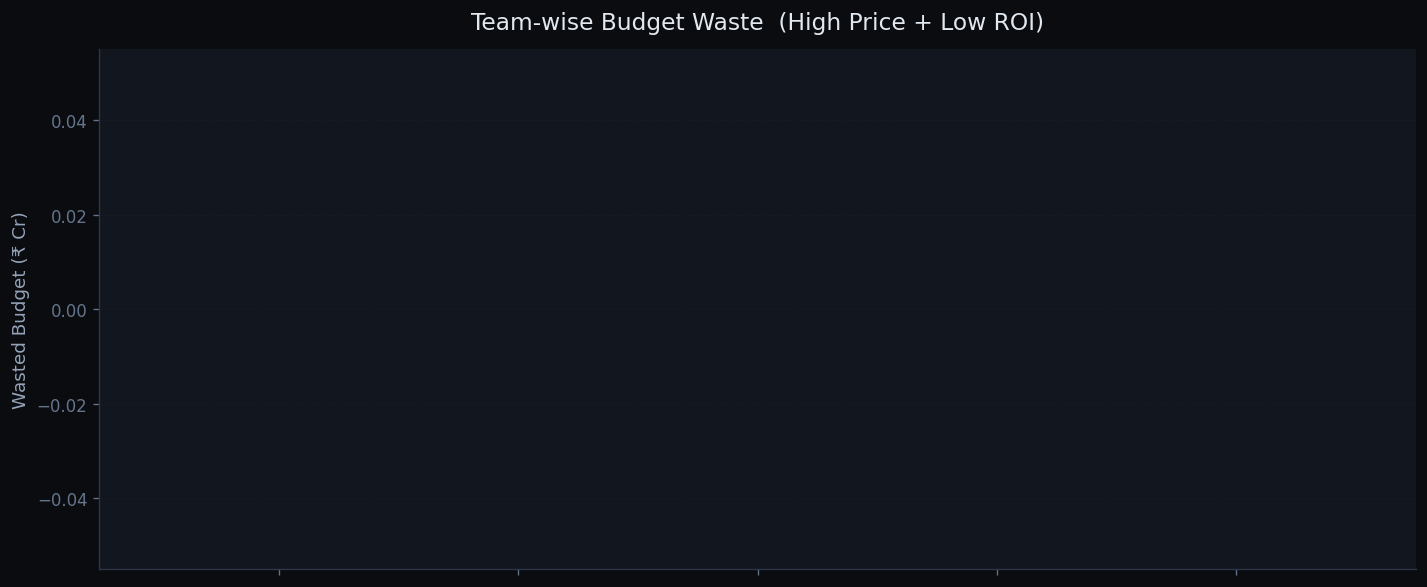

,Player,Team,Role,Price,ROI,Performance_Score


In [9]:
section("D) BENCH WARMERS · MONEY WASTED")

med_price = df["Price"].median()
q25_roi   = df["ROI"].quantile(0.25)
bench     = df[(df["Price"] > med_price) & (df["ROI"] < q25_roi)].copy()

print(f"  Median price threshold  : ₹{med_price/1e7:.2f} Cr")
print(f"  ROI 25th percentile     : {q25_roi:.4f}")
print(f"  Bench warmers identified: {len(bench)}\n")

# Team-wise wasted budget bar chart
wasted = bench.groupby("Team")["Price"].sum().sort_values(ascending=False) / 1e7

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
bar_colors = [PALETTE[1]] * len(wasted)
bars = ax.bar(wasted.index, wasted.values, color=bar_colors, edgecolor="#0a0c10", zorder=3)
for bar, val in zip(bars, wasted.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f"₹{val:.1f}Cr", ha="center", fontsize=9, color="#e2e8f0")
ax.set_xticklabels(wasted.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Wasted Budget (₹ Cr)")
ax.set_title("Team-wise Budget Waste  (High Price + Low ROI)", pad=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

show = [c for c in ["Player","Team","Role","Price","ROI","Performance_Score"] if c in bench.columns]
display(bench[show].sort_values("Price", ascending=False)
        .reset_index(drop=True)
        .style.background_gradient(subset=["ROI"], cmap="RdYlGn")
        .format({"Price":"₹{:.2e}","ROI":"{:.4f}","Performance_Score":"{:.2f}"}))


══════════════════════════════════════════════════════════════════════
  E) STATISTICAL ANALYSIS
══════════════════════════════════════════════════════════════════════


── Chi-Square Test — Role vs Capped Status ─────────────────────

  χ² Statistic        : 0.8048
  p-value             : 0.8483
  Degrees of Freedom  : 3

  ❌ NOT SIGNIFICANT (p ≥ 0.05)
     No strong evidence of association between Role and Capped status.

  Contingency Table:


Capped,0,1
Role,,
Allrounder,39,64
Batter,17,38
Bowler,38,73
WK-Batter,14,26



── Welch's T-Test — ROI: Capped vs Uncapped Players ────────────

  Capped players   : 201  |  Mean ROI = 13.1040
  Uncapped players : 108  |  Mean ROI = 7.1773

  T-Statistic  : 1.9789
  p-value      : 0.0488

  ✅ SIGNIFICANT (p < 0.05)
     Capped players deliver HIGHER average ROI than uncapped players.


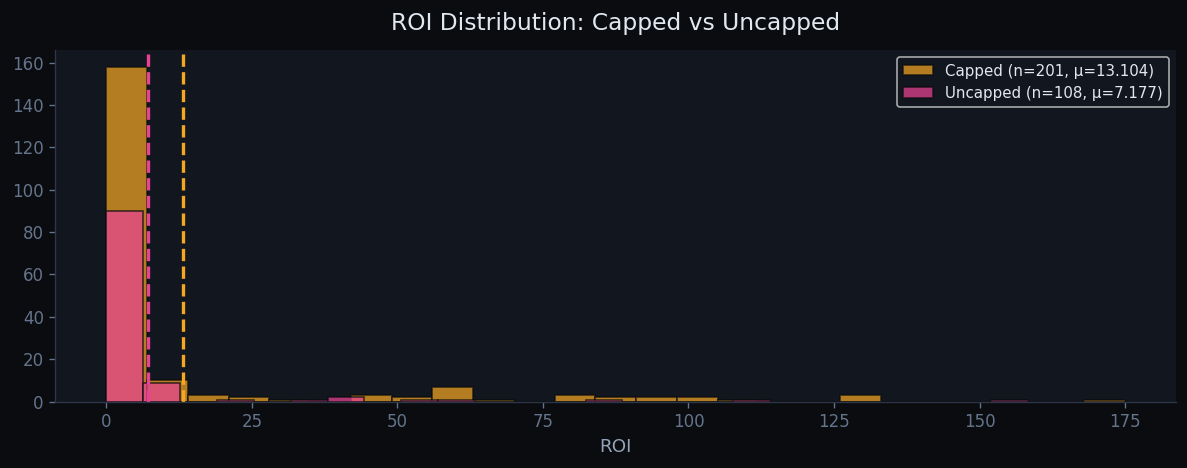

In [10]:
section("E) STATISTICAL ANALYSIS")

# ── Chi-Square: Role vs Capped ─────────────────────────────────────
subsection("Chi-Square Test — Role vs Capped Status")
try:
    contingency = pd.crosstab(df["Role"], df["Capped"])
    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

    print(f"  χ² Statistic        : {chi2:.4f}")
    print(f"  p-value             : {p_chi:.4f}")
    print(f"  Degrees of Freedom  : {dof}")

    if p_chi < 0.05:
        print("\n  ✅ SIGNIFICANT (p < 0.05)")
        print("     There IS a meaningful association between a player's Role")
        print("     and their Capped status.")
    else:
        print("\n  ❌ NOT SIGNIFICANT (p ≥ 0.05)")
        print("     No strong evidence of association between Role and Capped status.")

    print("\n  Contingency Table:")
    display(contingency)

except Exception as ex:
    print(f"  Chi-Square test failed: {ex}")

# ── T-Test: ROI capped vs uncapped ────────────────────────────────
subsection("Welch's T-Test — ROI: Capped vs Uncapped Players")
try:
    roi_capped   = df[df["Capped"] == 1]["ROI"].dropna()
    roi_uncapped = df[df["Capped"] == 0]["ROI"].dropna()

    print(f"  Capped players   : {len(roi_capped)}  |  Mean ROI = {roi_capped.mean():.4f}")
    print(f"  Uncapped players : {len(roi_uncapped)}  |  Mean ROI = {roi_uncapped.mean():.4f}")

    if len(roi_capped) < 2 or len(roi_uncapped) < 2:
        print("  ⚠️  Not enough data in one group to perform t-test.")
    else:
        t_stat, p_t = stats.ttest_ind(roi_capped, roi_uncapped, equal_var=False)
        print(f"\n  T-Statistic  : {t_stat:.4f}")
        print(f"  p-value      : {p_t:.4f}")

        if p_t < 0.05:
            direction = "HIGHER" if roi_capped.mean() > roi_uncapped.mean() else "LOWER"
            print(f"\n  ✅ SIGNIFICANT (p < 0.05)")
            print(f"     Capped players deliver {direction} average ROI than uncapped players.")
        else:
            print("\n  ❌ NOT SIGNIFICANT (p ≥ 0.05)")
            print("     No meaningful ROI difference between capped and uncapped players.")

        # Overlapping histogram
        fig, ax = plt.subplots(figsize=(10, 4))
        fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
        ax.hist(roi_capped,   bins=25, alpha=0.72, color=PALETTE[0],
                label=f"Capped (n={len(roi_capped)}, μ={roi_capped.mean():.3f})",
                edgecolor="#0a0c10")
        ax.hist(roi_uncapped, bins=25, alpha=0.72, color=PALETTE[1],
                label=f"Uncapped (n={len(roi_uncapped)}, μ={roi_uncapped.mean():.3f})",
                edgecolor="#0a0c10")
        ax.axvline(roi_capped.mean(),   color=PALETTE[0], lw=2, linestyle="--")
        ax.axvline(roi_uncapped.mean(), color=PALETTE[1], lw=2, linestyle="--")
        ax.set_xlabel("ROI")
        ax.set_title("ROI Distribution: Capped vs Uncapped", pad=12)
        ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()

except Exception as ex:
    print(f"  T-test failed: {ex}")


══════════════════════════════════════════════════════════════════════
  F) VISUAL ANALYSIS
══════════════════════════════════════════════════════════════════════


── 1 · ROI Distribution with KDE ───────────────────────────────



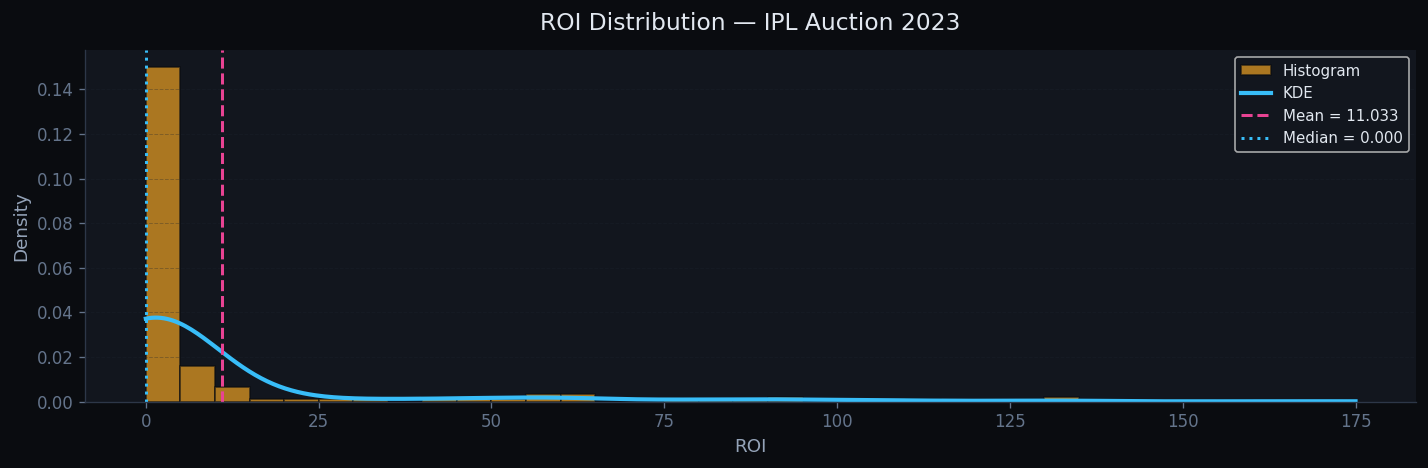


── 2 · ROI by Player Role (Box Plot) ───────────────────────────



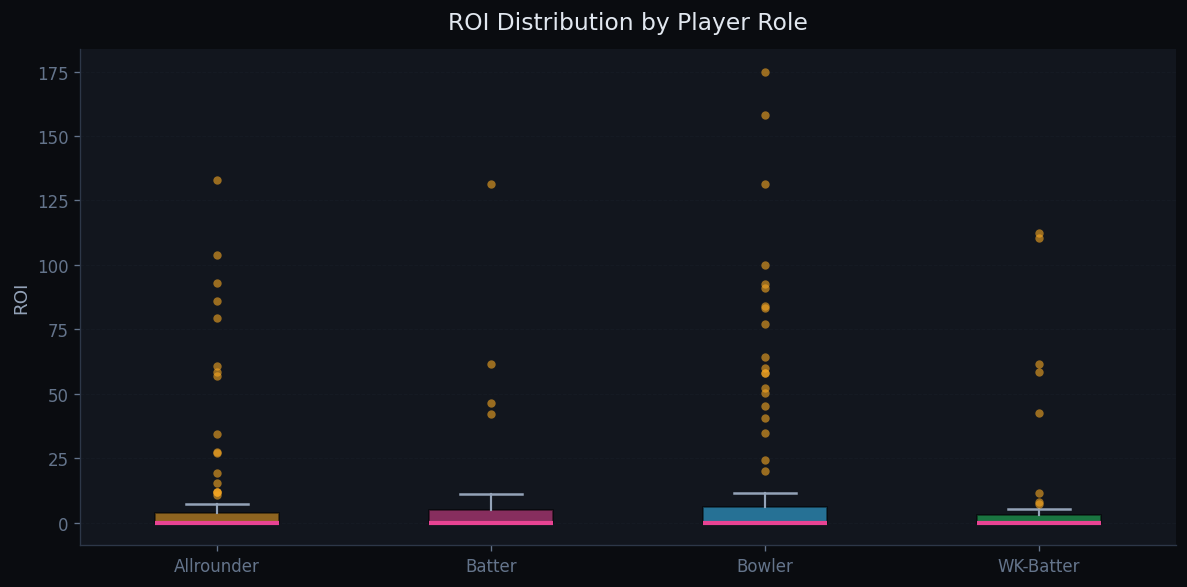


── 3 · Price vs Performance Score (Scatter) ────────────────────



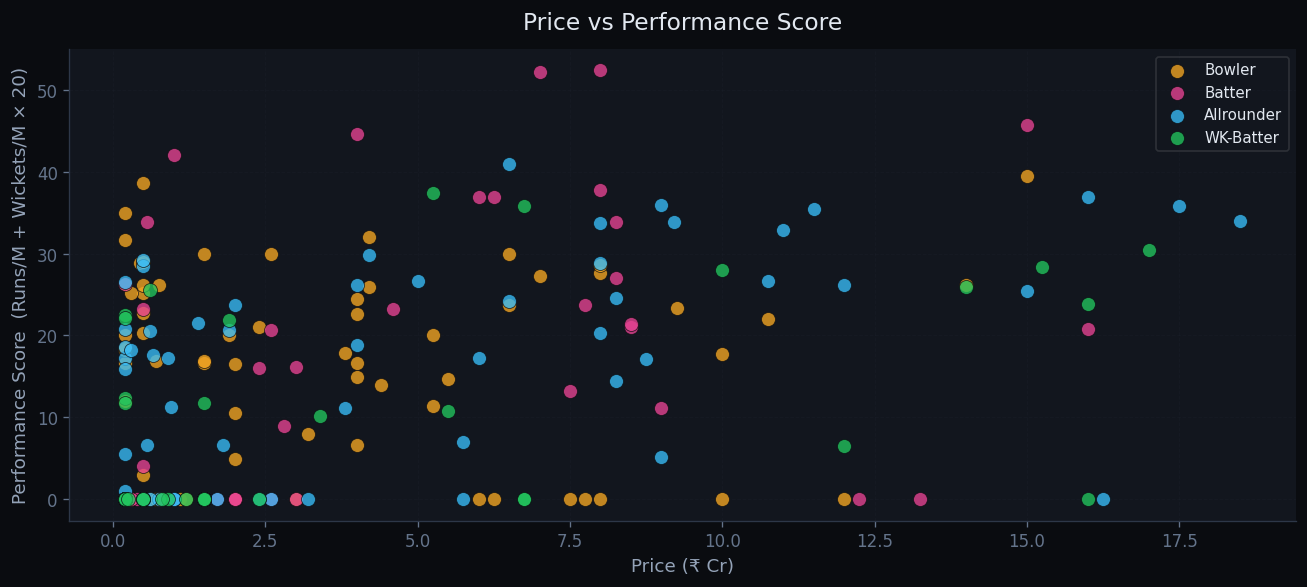


── 4 · Team-wise ROI Distribution (Box Plot) ───────────────────



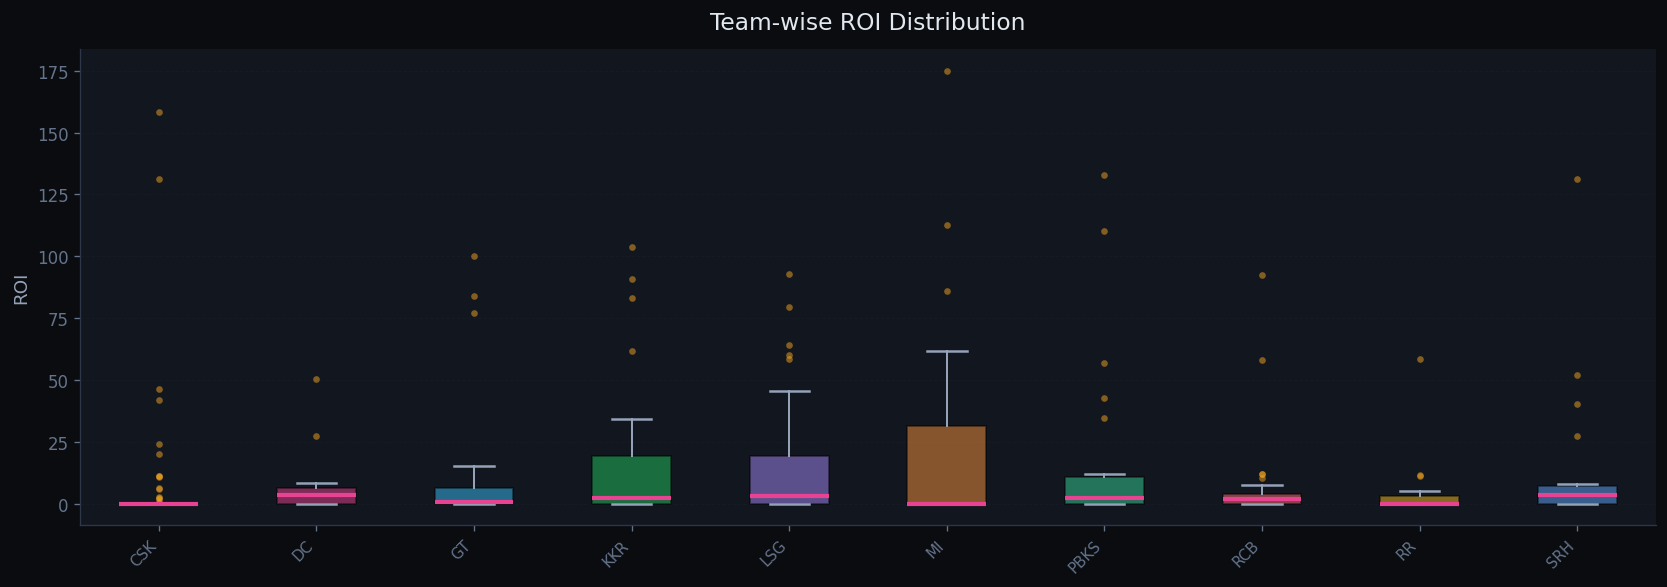


── 5 · Top vs Bottom ROI Players (Box Plot) ────────────────────



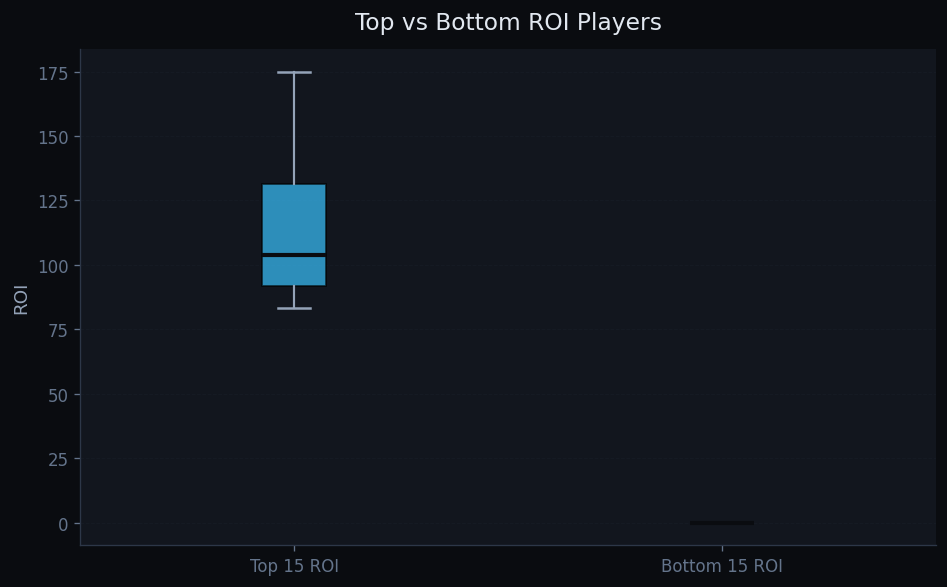


── 6 · Feature Correlation Heatmap ─────────────────────────────



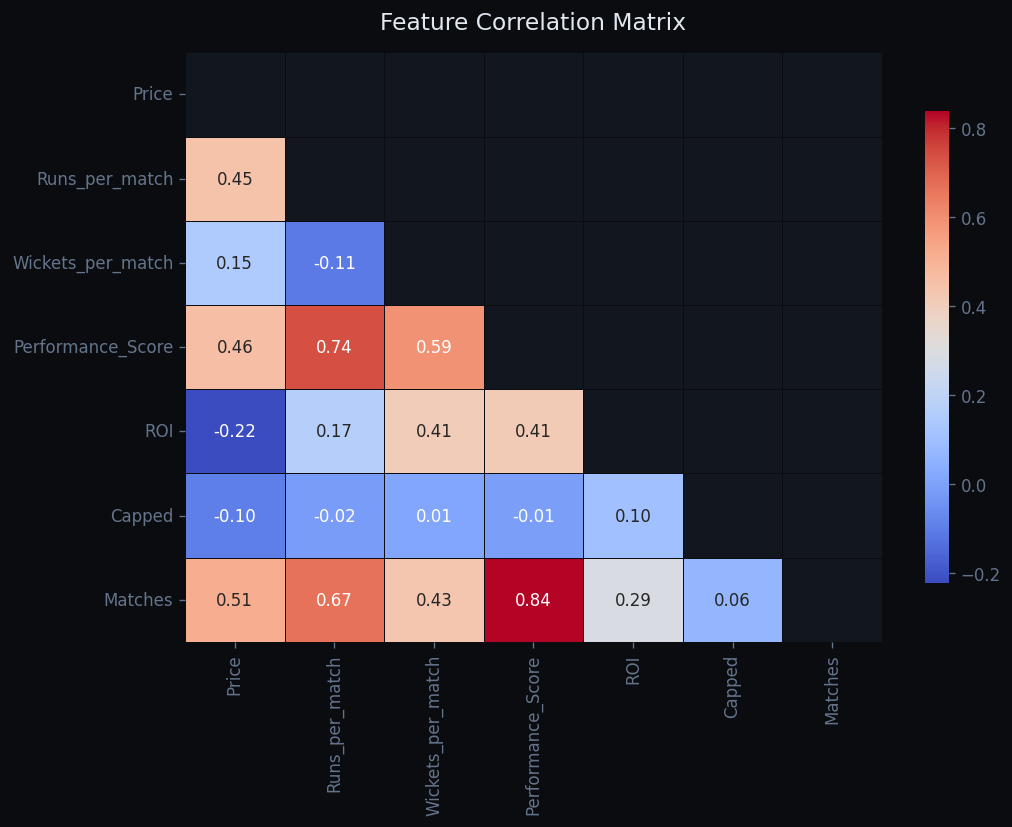



🏆  Analysis complete! All sections rendered above.


In [11]:
section("F) VISUAL ANALYSIS")

# ── 1. ROI Histogram + KDE ─────────────────────────────────────────
subsection("1 · ROI Distribution with KDE")
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
roi_vals = df["ROI"].dropna()
ax.hist(roi_vals, bins=35, color=PALETTE[0], alpha=0.68,
        edgecolor="#0a0c10", density=True, label="Histogram")
try:
    kde = stats.gaussian_kde(roi_vals)
    xr  = np.linspace(roi_vals.min(), roi_vals.max(), 400)
    ax.plot(xr, kde(xr), color="#38bdf8", lw=2.5, label="KDE")
except Exception:
    pass
ax.axvline(roi_vals.mean(),   color=PALETTE[1], lw=1.8, linestyle="--",
           label=f"Mean = {roi_vals.mean():.3f}")
ax.axvline(roi_vals.median(), color=PALETTE[2], lw=1.8, linestyle=":",
           label=f"Median = {roi_vals.median():.3f}")
ax.set_xlabel("ROI"); ax.set_ylabel("Density")
ax.set_title("ROI Distribution — IPL Auction 2023", pad=12)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── 2. Box plot: ROI vs Role ───────────────────────────────────────
subsection("2 · ROI by Player Role (Box Plot)")
roles = sorted(df["Role"].dropna().unique())
data_by_role = [df[df["Role"]==r]["ROI"].dropna() for r in roles]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
bp = ax.boxplot(data_by_role, labels=roles, patch_artist=True,
                whiskerprops={"color":"#94a3b8","linewidth":1.3},
                capprops={"color":"#94a3b8","linewidth":1.5},
                medianprops={"color":PALETTE[1],"linewidth":2.5},
                flierprops={"marker":"o","markerfacecolor":PALETTE[0],
                            "markersize":5,"alpha":0.6,"markeredgewidth":0})
for patch, color in zip(bp["boxes"], PALETTE[:len(roles)]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel("ROI"); ax.set_title("ROI Distribution by Player Role", pad=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── 3. Scatter: Price vs Performance ──────────────────────────────
subsection("3 · Price vs Performance Score (Scatter)")
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
for i, role in enumerate(df["Role"].dropna().unique()):
    sub = df[df["Role"] == role]
    ax.scatter(sub["Price"]/1e7, sub["Performance_Score"],
               label=role, alpha=0.78, s=70,
               color=PALETTE[i % len(PALETTE)],
               edgecolors="#0a0c10", linewidths=0.5, zorder=3)
ax.set_xlabel("Price (₹ Cr)")
ax.set_ylabel("Performance Score  (Runs/M + Wickets/M × 20)")
ax.set_title("Price vs Performance Score", pad=12)
ax.legend(fontsize=9, framealpha=0.15)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

# ── 4. Team-wise ROI box plot ──────────────────────────────────────
subsection("4 · Team-wise ROI Distribution (Box Plot)")
teams_sorted = sorted(df["Team"].dropna().unique())
data_by_team = [df[df["Team"]==t]["ROI"].dropna() for t in teams_sorted]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
bp2 = ax.boxplot(data_by_team, labels=teams_sorted, patch_artist=True,
                 whiskerprops={"color":"#94a3b8","linewidth":1.2},
                 capprops={"color":"#94a3b8","linewidth":1.5},
                 medianprops={"color":PALETTE[1],"linewidth":2.5},
                 flierprops={"marker":"o","markerfacecolor":PALETTE[0],
                             "markersize":4,"alpha":0.5,"markeredgewidth":0})
for patch, color in zip(bp2["boxes"], PALETTE * 5):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.set_xticklabels(teams_sorted, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("ROI"); ax.set_title("Team-wise ROI Distribution", pad=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── 5. Top vs Bottom ROI box plot ─────────────────────────────────
subsection("5 · Top vs Bottom ROI Players (Box Plot)")
n = max(5, min(15, len(df)//4))
top_roi    = df.nlargest(n,  "ROI")["ROI"]
bottom_roi = df.nsmallest(n, "ROI")["ROI"]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
bp3 = ax.boxplot([top_roi, bottom_roi],
                 labels=[f"Top {n} ROI", f"Bottom {n} ROI"],
                 patch_artist=True,
                 whiskerprops={"color":"#94a3b8","linewidth":1.3},
                 capprops={"color":"#94a3b8","linewidth":1.5},
                 medianprops={"color":"#0a0c10","linewidth":2.5},
                 flierprops={"marker":"o","markersize":6,"alpha":0.6,"markeredgewidth":0})
bp3["boxes"][0].set_facecolor(PALETTE[2]); bp3["boxes"][0].set_alpha(0.72)
bp3["boxes"][1].set_facecolor(PALETTE[1]); bp3["boxes"][1].set_alpha(0.72)
ax.set_ylabel("ROI"); ax.set_title("Top vs Bottom ROI Players", pad=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ── 6. Correlation Heatmap ─────────────────────────────────────────
subsection("6 · Feature Correlation Heatmap")
num_cols  = df.select_dtypes(include=np.number).columns.tolist()
corr_cols = [c for c in ["Price","Runs_per_match","Wickets_per_match",
                          "Performance_Score","ROI","Capped","Matches"]
             if c in num_cols]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#0a0c10"); ax.set_facecolor("#12161e")
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.6, linecolor="#0a0c10",
            annot_kws={"size":10}, ax=ax,
            cbar_kws={"shrink":0.8})
ax.set_title("Feature Correlation Matrix", pad=14)
plt.tight_layout(); plt.show()

print("\n\n🏆  Analysis complete! All sections rendered above.")